In [4]:
## load stuff and the target sequences from pkl
import os, sys, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

REPO = '/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
import eigen_steering
from eigen_steering import EigenMap

eigen_steering.WEIGHTS_PATH = os.path.join(REPO, 'pytorch_base_model', 'model_fold_0.safetensors')
CT = {'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

df = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
df = df.dropna(subset=['sequence'] + [f'{ct}_log2FC' for ct in CT]).reset_index(drop=True)

em = EigenMap(model_names=CT, device=DEVICE)
em.load_from_dataframe(df, seq_col='sequence')
em.set_actual({ct: df[f'{ct}_log2FC'].values for ct in CT})

raw = np.load(os.path.join(REPO, 'genomic_targets', 'data', 'deeplift_attributions.npz'))
df_full = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
seq_valid = df_full['sequence'].notna(); n = seq_valid.sum()
keep = df_full.loc[seq_valid, ['sequence'] + [f'{ct}_log2FC' for ct in CT]].notna().all(axis=1).values
del df_full

ohe = em.X.numpy()
for ct in CT:
    hyp = raw[f'attr_{ct}'][:n][keep]
    em.attr_hyp[ct] = hyp; em.attr[ct] = hyp * ohe
    em.importance[ct] = em.attr[ct].sum(axis=1)
    em.predictions[ct] = raw[f'predictions_{ct}'][:n][keep]

cossim = em.cosine_similarity(mode='importance', zscore=True)
lfc = (df['HepG2_log2FC'] - df['K562_log2FC']).values

with open(os.path.join(REPO, 'virtual_perturbations/diff_call/results/target_loci_library.pkl'), 'rb') as f:
    target_lib = pickle.load(f)
target_df = target_lib['df'] if isinstance(target_lib, dict) and 'df' in target_lib else target_lib
target_idx = np.asarray(target_df['seq_idx'].values)
print(f'target seqs: {len(target_idx)}')

EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
Loaded 56975 sequences, X shape: torch.Size([56975, 4, 281])
target seqs: 8


In [ ]:
# show selected seqs on func,mech space
fin = np.isfinite(cossim) & np.isfinite(lfc)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(lfc[fin], cossim[fin], s=4, c='lightgray', alpha=0.5, edgecolors='none', label='full lib')
ax.scatter(lfc[target_idx], cossim[target_idx], s=60, c='crimson', edgecolors='black', linewidths=0.5, label=f'target ({len(target_idx)})')
for s in target_idx:
    ax.annotate(str(s), (lfc[s], cossim[s]), fontsize=7, xytext=(3, 3), textcoords='offset points')
ax.axhline(0, c='k', lw=0.5); ax.axvline(0, c='k', lw=0.5)
ax.set_xlabel('log2FC HepG2 / K562  (functional)')
ax.set_ylabel('attribution cosine similarity  (mechanistic)')
ax.legend()
plt.tight_layout()

FG: 8/8 | BG: 8/8


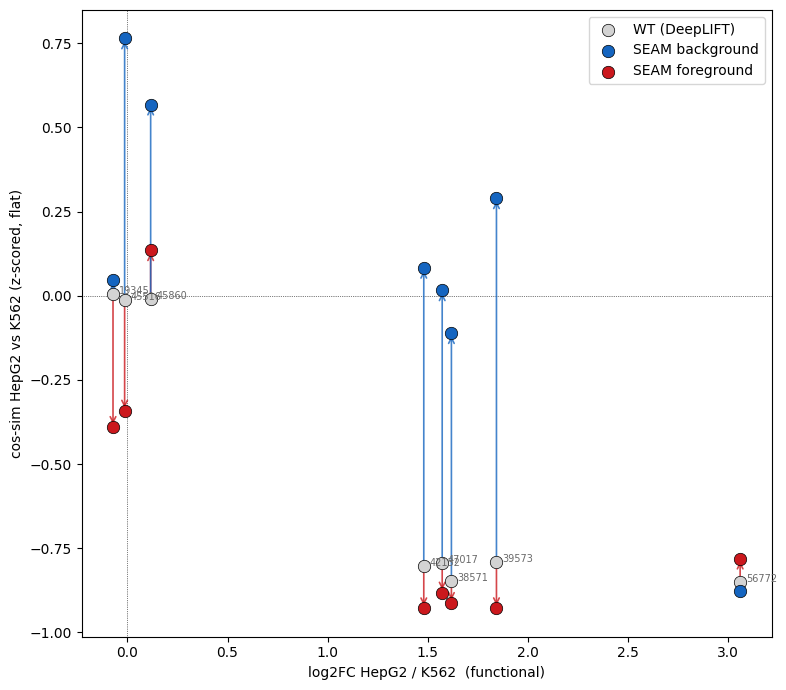

In [14]:
# targets only on func/mech space: WT (gray) -> SEAM foreground (red) and SEAM background (blue)
FG_DIR = os.path.join(REPO, 'SEAM_target_spaces', 'results', 'foregrounds')

def _zflat(a):
    a = a.astype(np.float64).ravel()
    s = a.std()
    return (a - a.mean()) / s if s > 0 else a - a.mean()

def _cos(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(a @ b / (na * nb)) if na > 0 and nb > 0 else np.nan

cos_fg = np.full(len(target_idx), np.nan)
cos_bg = np.full(len(target_idx), np.nan)
for i, sid in enumerate(target_idx):
    try:
        fH = _zflat(np.load(f'{FG_DIR}/HepG2/{sid}/foreground_scaled.npy'))
        fK = _zflat(np.load(f'{FG_DIR}/K562/{sid}/foreground_scaled.npy'))
        bH = _zflat(np.load(f'{FG_DIR}/HepG2/{sid}/average_background_scaled.npy'))
        bK = _zflat(np.load(f'{FG_DIR}/K562/{sid}/average_background_scaled.npy'))
        cos_fg[i] = _cos(fH, fK)
        cos_bg[i] = _cos(bH, bK)
    except FileNotFoundError:
        pass
print(f'FG: {np.isfinite(cos_fg).sum()}/{len(target_idx)} | BG: {np.isfinite(cos_bg).sum()}/{len(target_idx)}')

x = lfc[target_idx]
cos_wt = cossim[target_idx]

fig, ax = plt.subplots(figsize=(8, 7))
for i in range(len(target_idx)):
    ax.annotate('', xy=(x[i], cos_fg[i]), xytext=(x[i], cos_wt[i]),
                arrowprops=dict(arrowstyle='->', color='#cb181d', lw=1.2, alpha=0.8))
    ax.annotate('', xy=(x[i], cos_bg[i]), xytext=(x[i], cos_wt[i]),
                arrowprops=dict(arrowstyle='->', color='#1565C0', lw=1.2, alpha=0.8))
ax.scatter(x, cos_wt, s=80, c='lightgray', edgecolors='black', linewidths=0.5, label='WT (DeepLIFT)', zorder=3)
ax.scatter(x, cos_bg, s=80, c='#1565C0',   edgecolors='black', linewidths=0.5, label='SEAM background', zorder=3)
ax.scatter(x, cos_fg, s=80, c='#cb181d',   edgecolors='black', linewidths=0.5, label='SEAM foreground', zorder=3)
for i, sid in enumerate(target_idx):
    ax.annotate(str(sid), (x[i], cos_wt[i]), fontsize=7, xytext=(4, 0), textcoords='offset points', color='dimgray')
ax.axhline(0, c='k', lw=0.5, ls=':'); ax.axvline(0, c='k', lw=0.5, ls=':')
ax.set_xlabel('log2FC HepG2 / K562  (functional)')
ax.set_ylabel('cos-sim HepG2 vs K562 (z-scored, flat)')
ax.legend()
plt.tight_layout()

  HepG2: 2 motif hits (p<0.05)
  K562: 3 motif hits (p<0.05)
  HepG2: 2 hits
    [155-196] HNF1B(p=2.6e-04), HNF1A(p=3.1e-04), PHOX2B(p=3.7e-04)  (enhancer)
    [ 32- 73] ZEB1(p=1.4e-04), FOXN3(p=8.6e-04), ZEB2(p=1.5e-03)  (enhancer)
  K562: 3 hits
    [158-199] HNF1B(p=2.6e-04), HNF1A(p=3.1e-04), PHOX2B(p=3.8e-04)  (enhancer)
    [ 51- 92] BHLHE22(p=1.7e-07), Twist2(p=2.4e-06), Neurod2(p=2.4e-06)  (enhancer)
    [ 13- 54] ZNF692(p=3.4e-04), Ahr::Arnt(p=6.3e-04), FOXN3(p=8.4e-04)  (enhancer)
  HepG2: 2 motif hits (p<0.05)
  K562: 4 motif hits (p<0.05)
  HepG2: 2 hits
    [155-196] HNF1B(p=2.6e-04), HNF1A(p=3.1e-04), PHOX2B(p=3.7e-04)  (enhancer)
    [191-232] EWSR1-FLI1(p=7.0e-04), Ahr::Arnt(p=1.1e-03), ZNF281(p=1.6e-03)  (promoter)
  K562: 4 hits
    [ 32- 73] ZEB1(p=1.4e-04), FOXN3(p=8.6e-04), ZEB2(p=1.5e-03)  (enhancer)
    [168-209] HNF1B(p=2.6e-04), HNF1A(p=3.1e-04), PHOX2B(p=3.7e-04)  (enhancer)
    [ 10- 51] ZNF692(p=3.4e-04), Ahr::Arnt(p=6.2e-04), FOXN3(p=8.4e-04)  (enhancer)
 

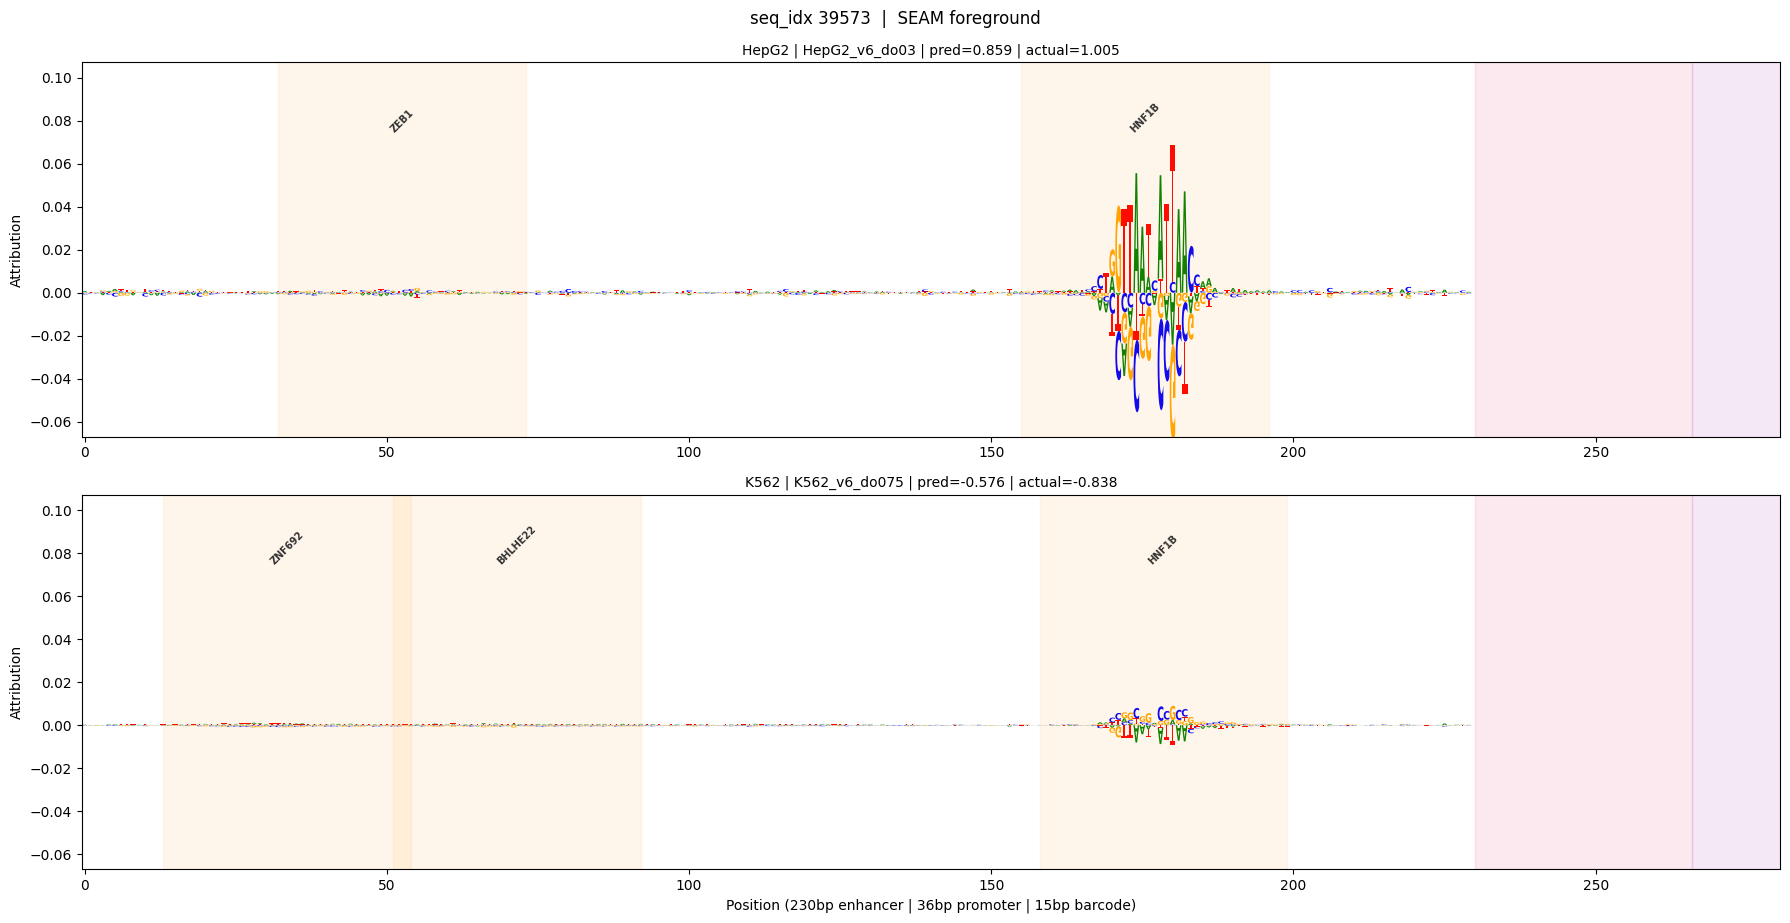

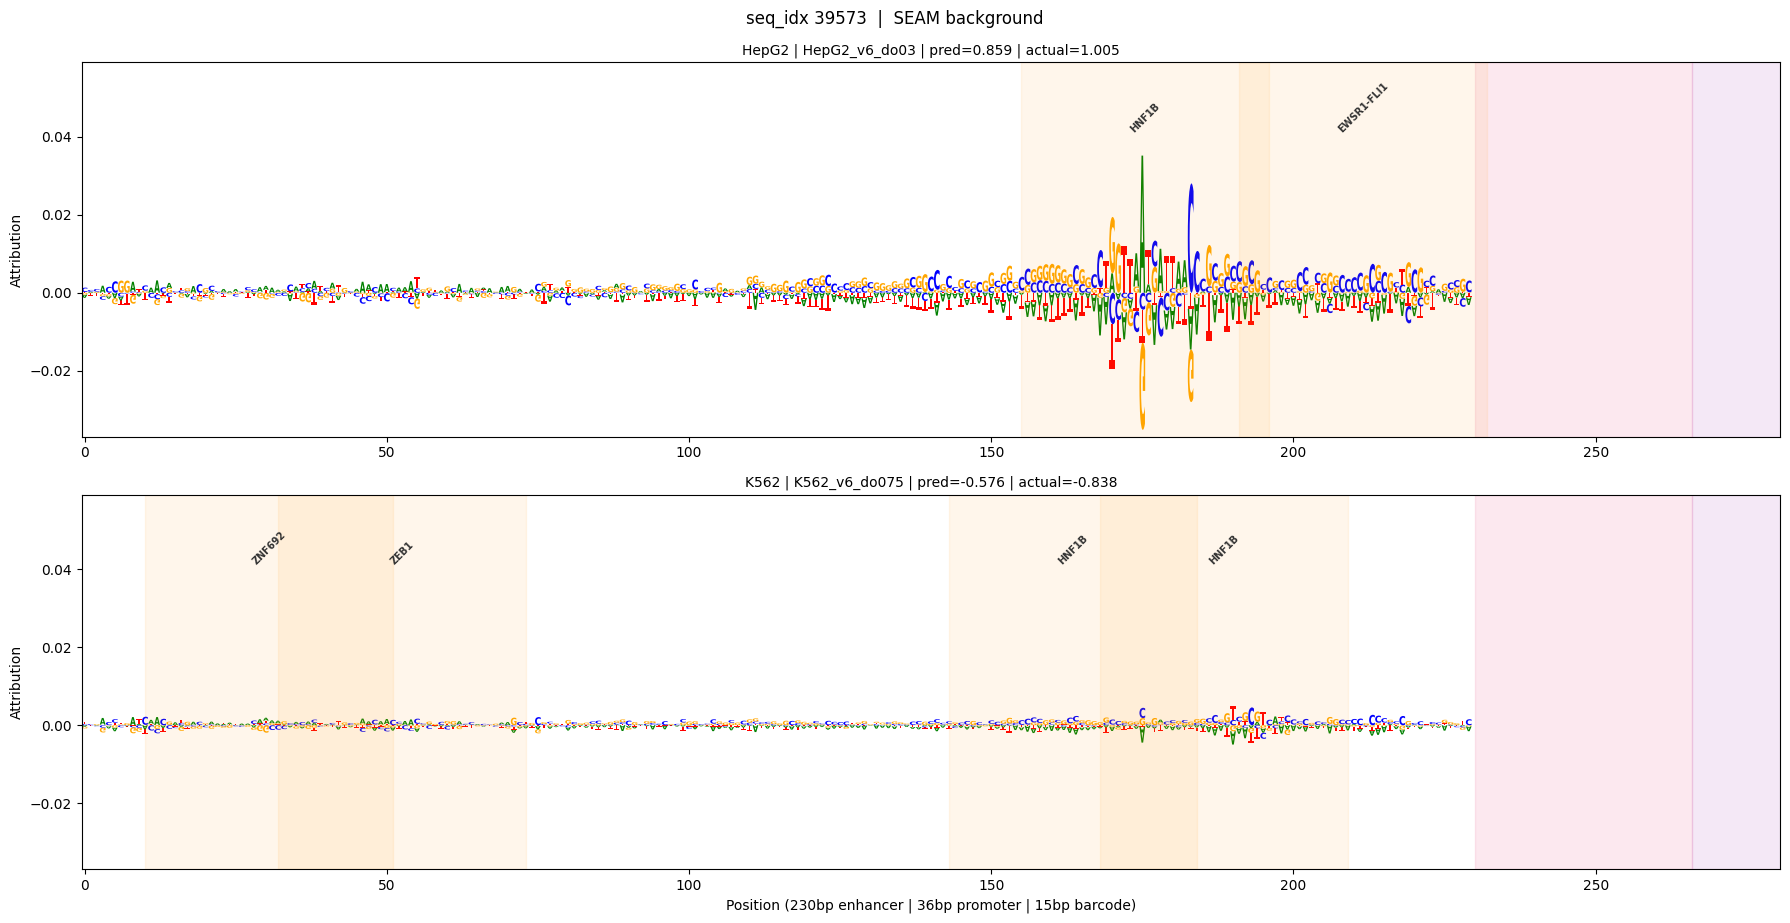

In [27]:
# pick a target seq, view SEAM foreground vs background logos with seqlet/motif annotations
import copy
SID = 39573                                   # <-- change me
s = int(SID)
ENH = 230                                     # SEAM tracks span enhancer only

def _seam_em(kind, project_ohe=False):
    em_s = copy.copy(em)
    em_s.cell_types = ['HepG2', 'K562']
    em_s.X = em.X[s:s+1]
    em_s.constructs = [em.constructs[s]]
    ohe_4L = em.X[s].numpy()                  # (4, 281)
    fname = 'foreground_scaled.npy' if kind == 'fg' else 'average_background_scaled.npy'
    em_s.attr, em_s.attr_hyp, em_s.importance, em_s.predictions, em_s.actual = {}, {}, {}, {}, {}
    for ct in ('HepG2', 'K562'):
        a = np.load(f'{FG_DIR}/{ct}/{SID}/{fname}')
        if a.shape[-1] != 4: a = a.T          # (L, 4)
        attr_4L = np.zeros_like(ohe_4L)
        attr_4L[:, :ENH] = a.T                # pad to 281, channels-first
        if project_ohe:
            attr_4L = attr_4L * ohe_4L
        em_s.attr[ct]       = attr_4L[None]   # (1, 4, 281)
        em_s.attr_hyp[ct]   = attr_4L[None]
        em_s.importance[ct] = attr_4L.sum(0)[None]
        em_s.predictions[ct] = np.array([em.predictions[ct][s]])
        if ct in em.actual and em.actual[ct] is not None:
            em_s.actual[ct] = np.array([em.actual[ct][s]])
    return em_s

for kind, label in (('fg', 'SEAM foreground'), ('bg', 'SEAM background')):
    em_s = _seam_em(kind)
    em_s.annotate_motifs()                    # seqlet call + TOMTOM
    em_s.show_motifs(seq_idx=0)
    fig, axes = em_s.plot_attr_logos_with_motifs(seq_idx=0)
    fig.suptitle(f'seq_idx {SID}  |  {label}', fontsize=12, y=1.02)

  HepG2: 2 motif hits (p<0.05)
  K562: 3 motif hits (p<0.05)
  HepG2: 2 hits
    [155-196] HNF1B(p=2.6e-04), HNF1A(p=3.1e-04), PHOX2B(p=3.7e-04)  (enhancer)
    [ 32- 73] ZEB1(p=1.4e-04), FOXN3(p=8.6e-04), ZEB2(p=1.5e-03)  (enhancer)
  K562: 3 hits
    [158-199] HNF1B(p=2.6e-04), HNF1A(p=3.1e-04), PHOX2B(p=3.8e-04)  (enhancer)
    [ 51- 92] BHLHE22(p=1.7e-07), Twist2(p=2.4e-06), Neurod2(p=2.4e-06)  (enhancer)
    [ 13- 54] ZNF692(p=3.4e-04), Ahr::Arnt(p=6.3e-04), FOXN3(p=8.4e-04)  (enhancer)
  HepG2: 2 motif hits (p<0.05)
  K562: 4 motif hits (p<0.05)
  HepG2: 2 hits
    [155-196] HNF1B(p=2.6e-04), HNF1A(p=3.1e-04), PHOX2B(p=3.7e-04)  (enhancer)
    [191-232] EWSR1-FLI1(p=7.0e-04), Ahr::Arnt(p=1.1e-03), ZNF281(p=1.6e-03)  (promoter)
  K562: 4 hits
    [ 32- 73] ZEB1(p=1.4e-04), FOXN3(p=8.6e-04), ZEB2(p=1.5e-03)  (enhancer)
    [168-209] HNF1B(p=2.6e-04), HNF1A(p=3.1e-04), PHOX2B(p=3.7e-04)  (enhancer)
    [ 10- 51] ZNF692(p=3.4e-04), Ahr::Arnt(p=6.2e-04), FOXN3(p=8.4e-04)  (enhancer)
 

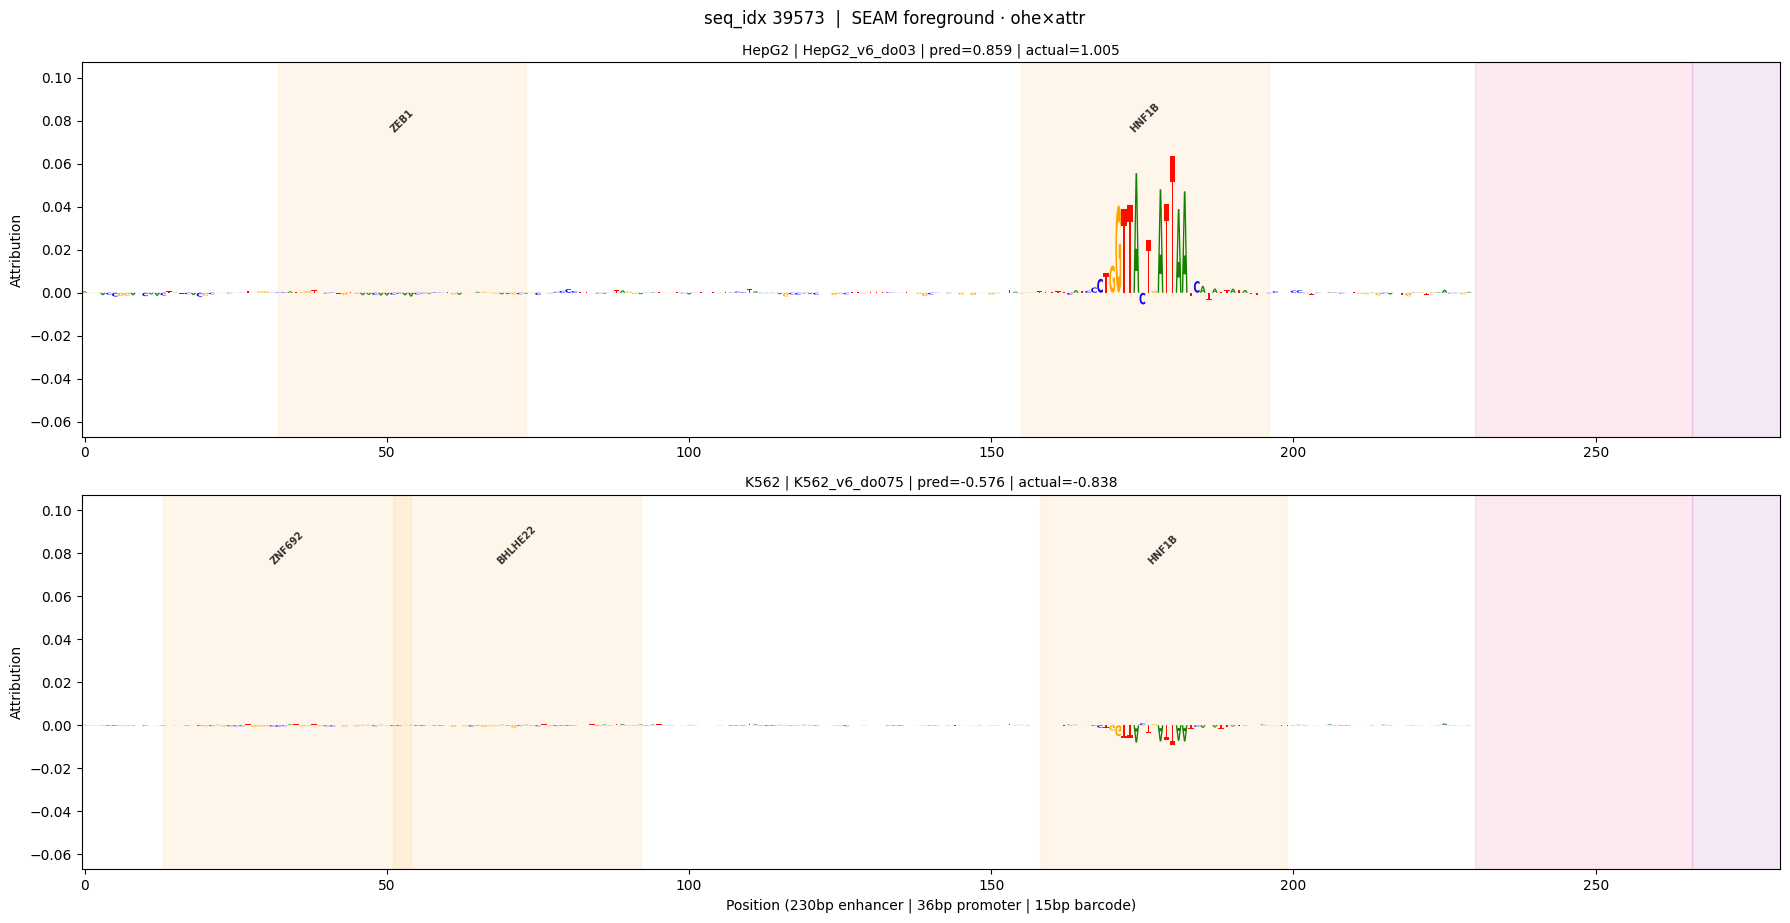

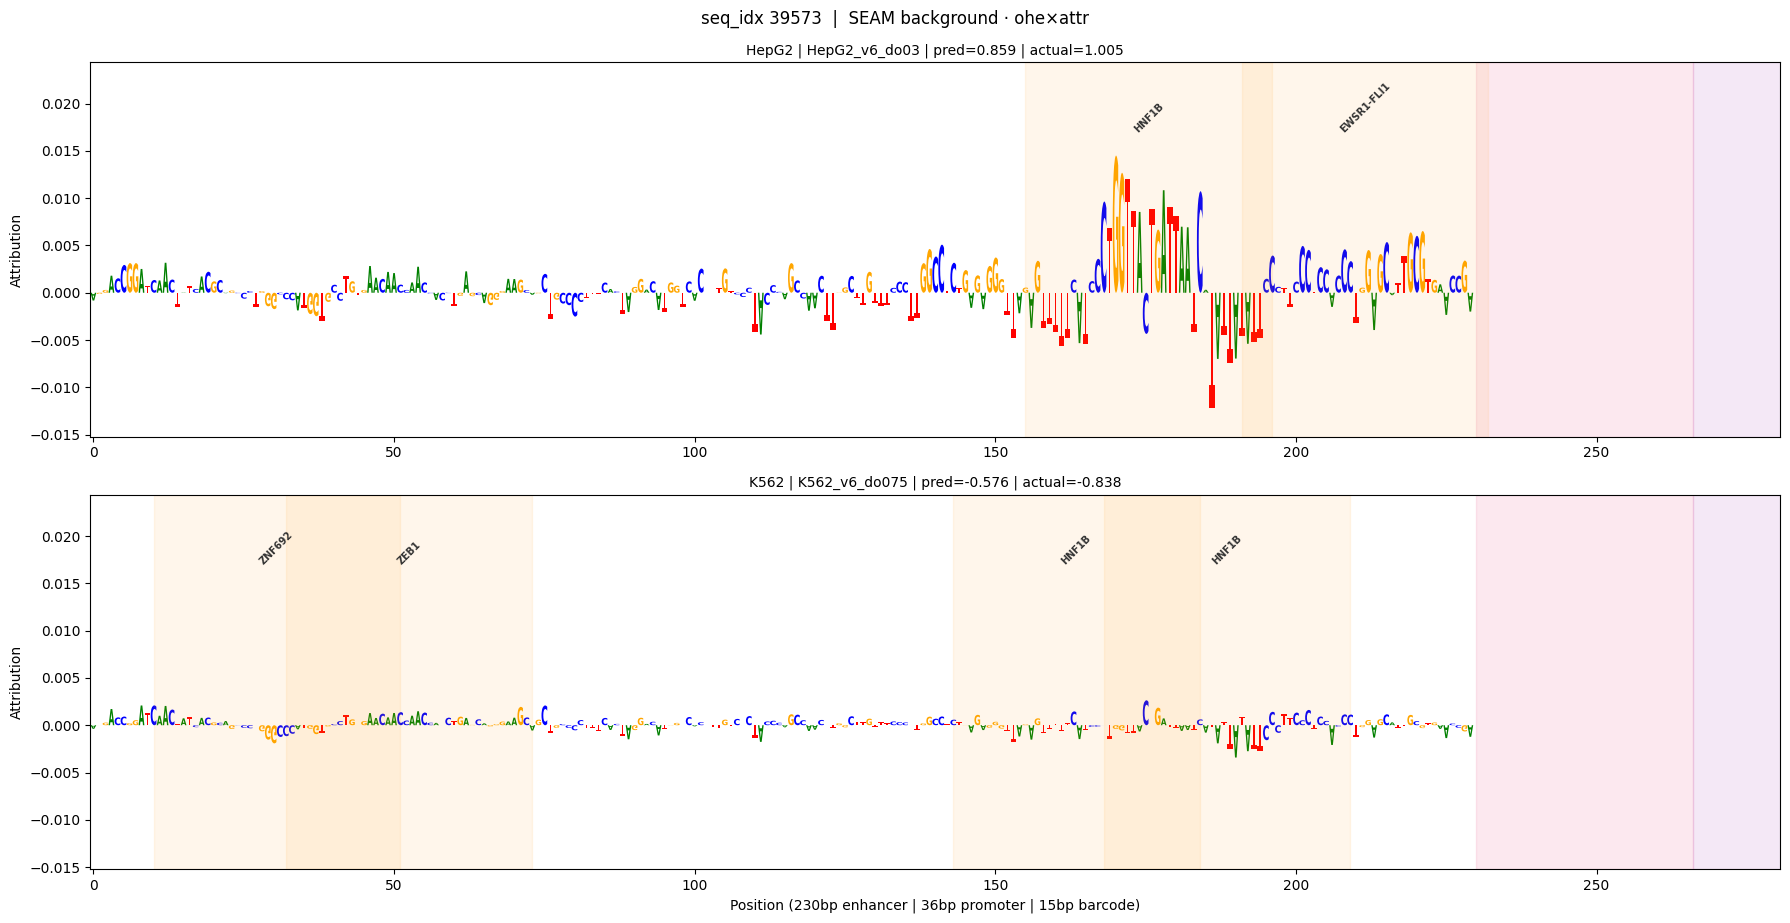

In [28]:
# same plots but ohe * attr (projected to actual base) — uses SID/s/_seam_em from cell above
for kind, label in (('fg', 'SEAM foreground · ohe×attr'), ('bg', 'SEAM background · ohe×attr')):
    em_s = _seam_em(kind, project_ohe=True)
    em_s.annotate_motifs()
    em_s.show_motifs(seq_idx=0)
    fig, axes = em_s.plot_attr_logos_with_motifs(seq_idx=0)
    fig.suptitle(f'seq_idx {SID}  |  {label}', fontsize=12, y=1.02)